##**Importing the Rice Dataset**




In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rice-image-dataset


## **Importing necessary libararies**

---



In [4]:
!pip install opencv-python
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns

## **Reading about data**

In [5]:
arborio=os.listdir(r"/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Arborio")
basmati=os.listdir(r"/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Basmati")
ipsala=os.listdir(r"/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala")
jasmine=os.listdir(r"/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Jasmine")
karacadag=os.listdir(r"/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Karacadag")

In [6]:
print(f"Number of image present in arborio file : ",len(arborio))
print(f"Number of image present in basmati file : ",len(basmati))
print(f"Number of image present in ipsala file : ",len(ipsala))
print(f"Number of image present in jasmine file : ",len(jasmine))
print(f"Number of image present in karacadag file : ",len(karacadag))

Number of image present in arborio file :  15000
Number of image present in basmati file :  15000
Number of image present in ipsala file :  15000
Number of image present in jasmine file :  15000
Number of image present in karacadag file :  15000


In [7]:
print("Sample of arborio:\n",arborio[:1001])
print("="*50)
print("Sample of basmati:\n",basmati[:1001])
print("="*50)
print("Sample of ipsala:\n",ipsala[:1001])
print("="*50)
print("Sample of jasmine:\n",jasmine[:1001])
print("="*50)
print("Sample of karacadag:\n",karacadag[:1001])

Sample of arborio:
 ['Arborio (5529).jpg', 'Arborio (3530).jpg', 'Arborio (2360).jpg', 'Arborio (154).jpg', 'Arborio (4561).jpg', 'Arborio (10804).jpg', 'Arborio (3922).jpg', 'Arborio (2417).jpg', 'Arborio (1163).jpg', 'Arborio (11902).jpg', 'Arborio (458).jpg', 'Arborio (11237).jpg', 'Arborio (1177).jpg', 'Arborio (9586).jpg', 'Arborio (3795).jpg', 'Arborio (2331).jpg', 'Arborio (1993).jpg', 'Arborio (7224).jpg', 'Arborio (7440).jpg', 'Arborio (10327).jpg', 'Arborio (10607).jpg', 'Arborio (3354).jpg', 'Arborio (5032).jpg', 'Arborio (4620).jpg', 'Arborio (4507).jpg', 'Arborio (13253).jpg', 'Arborio (4087).jpg', 'Arborio (13212).jpg', 'Arborio (6039).jpg', 'Arborio (214).jpg', 'Arborio (9508).jpg', 'Arborio (5745).jpg', 'Arborio (9307).jpg', 'Arborio (7951).jpg', 'Arborio (5353).jpg', 'Arborio (10509).jpg', 'Arborio (11269).jpg', 'Arborio (7630).jpg', 'Arborio (929).jpg', 'Arborio (11275).jpg', 'Arborio (7246).jpg', 'Arborio (8351).jpg', 'Arborio (10199).jpg', 'Arborio (13536).jpg', 'Ar

##**Checking 6 Image of type of rice**

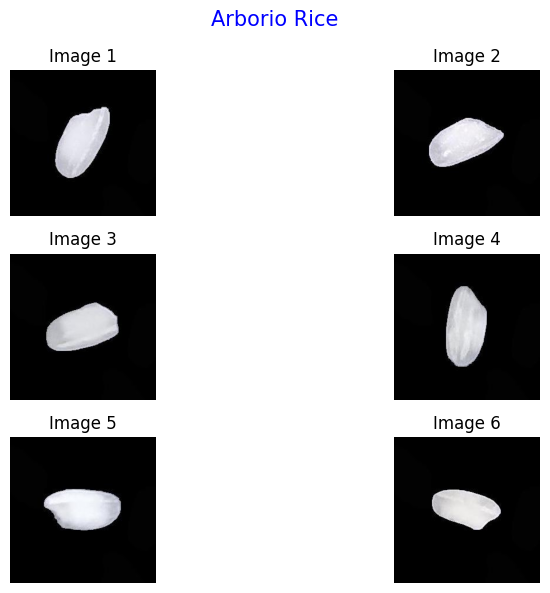

In [8]:
arborio_folder="/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Arborio"
plt.figure(figsize=(10,6))
plt.suptitle("Arborio Rice",color="Blue",fontsize=15)
for idx,paths in enumerate(arborio[:6]):
    join_path=os.path.join(arborio_folder,paths)
    img=mpimg.imread(join_path)
    plt.subplot(3,2,idx + 1)
    implot=plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {idx+1}")
plt.tight_layout()
plt.show()

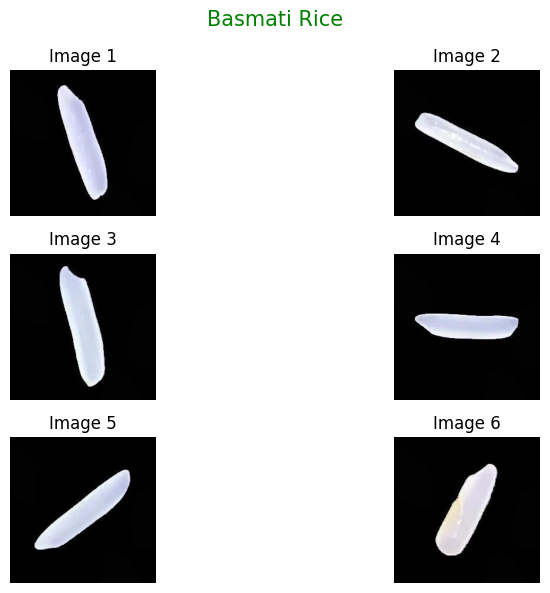

In [9]:
Basmati_folder="/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Basmati"
plt.figure(figsize=(10,6))
plt.suptitle("Basmati Rice",color="Green",fontsize=15)
for idx,paths in enumerate(basmati[:6]):
    plt.subplot(3,2,idx + 1)
    join_path=os.path.join(Basmati_folder,paths)
    img=mpimg.imread(join_path)
    plt.imshow(img)
    plt.axis("Off")
    plt.title(f"Image {idx+1}")
plt.tight_layout()
plt.show()

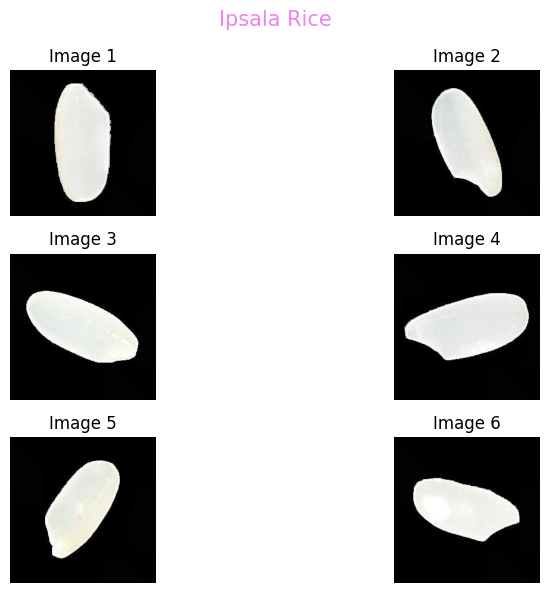

In [10]:
ipsala_folder="/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala"
plt.figure(figsize=(10,6))
plt.suptitle("Ipsala Rice",color="violet",fontsize=15)
for idx,paths in enumerate(ipsala[:6]):
    plt.subplot(3,2,idx + 1)
    join_path=os.path.join(ipsala_folder,paths)
    img=mpimg.imread(join_path)
    plt.imshow(img)
    plt.axis("Off")
    plt.title(f"Image {idx+1}")
plt.tight_layout()
plt.show()

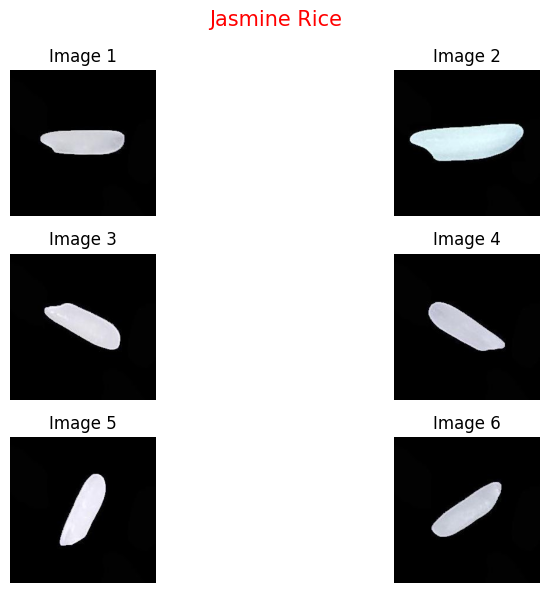

In [11]:
jasmine_folder="/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Jasmine"
plt.figure(figsize=(10,6))
plt.suptitle("Jasmine Rice",color="Red",fontsize=15)
for idx,paths in enumerate(jasmine[:6]):
    plt.subplot(3,2,idx + 1)
    join_path=os.path.join(jasmine_folder,paths)
    img=mpimg.imread(join_path)
    plt.imshow(img)
    plt.axis("Off")
    plt.title(f"Image {idx+1}")
plt.tight_layout()
plt.show()

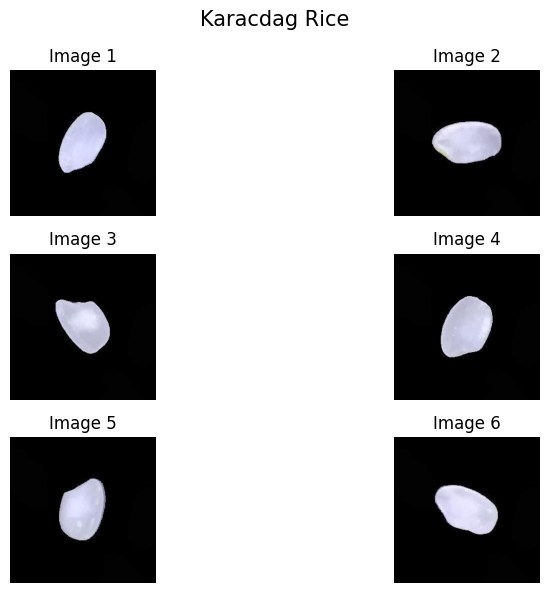

In [12]:
karacadag_folder="/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Karacadag"
plt.figure(figsize=(10,6))
plt.suptitle("Karacdag Rice",color="black",fontsize=15)
for idx,paths in enumerate(karacadag[:6]):
    plt.subplot(3,2,idx + 1)
    join_path=os.path.join(karacadag_folder,paths)
    img=mpimg.imread(join_path)
    plt.imshow(img)
    plt.axis("Off")
    plt.title(f"Image {idx+1}")
plt.tight_layout()
plt.show()

## **Preprocessing Image**

In [14]:
def image_preprocess_optimized_single_thread(base_dataset_path, class_folders, num_images_per_class=2000):
    all_images = []
    for class_name in class_folders:
        folder_path = os.path.join(base_dataset_path, class_name)
        if not folder_path.endswith(os.sep):
            folder_path += os.sep

        filenames = os.listdir(folder_path)

        # Ensure we don't exceed the available images
        num_images = min(num_images_per_class, len(filenames))

        # Randomly sample `num_images` filenames
        sampled_filenames = random.sample(filenames, num_images)

        for filename in sampled_filenames:
            image_path = os.path.join(folder_path, filename)
            try:
                image = Image.open(image_path)
                image = image.resize((250, 250))  # Resize to 128x128
                image = image.convert("RGB")       # Ensure RGB format
                all_images.append(np.array(image))
            except Exception as e:
                print(f"Error processing {image_path}: {e}")
                continue
    return all_images

base_dataset_path = "/kaggle/input/rice-image-dataset/Rice_Image_Dataset/"
class_folders = ["Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag"]

print("Starting optimized single-threaded image preprocessing (2000 images per class)...")
data = image_preprocess_optimized_single_thread(base_dataset_path, class_folders)
print(f"Finished preprocessing. Total images loaded: {len(data)}")

Starting optimized single-threaded image preprocessing (2000 images per class)...
Finished preprocessing. Total images loaded: 10000


##**Labelling the rice**

In [15]:
num_images_per_class = 2000

# Limit each class to 2000 images
arborio = arborio[:num_images_per_class]
basmati = basmati[:num_images_per_class]
ipsala = ipsala[:num_images_per_class]
jasmine = jasmine[:num_images_per_class]
karacadag = karacadag[:num_images_per_class]

# Create labels (0-4) for 2000 images per class
Arborio_label = [0] * len(arborio)  # label=0 (Arborio)
Basmati_label = [1] * len(basmati)   # label=1 (Basmati)
Jasmine_label = [2] * len(jasmine)   # label=2 (Jasmine)
Karacadag_label = [3] * len(karacadag)  # label=3 (Karacadag)
Ipsala_label = [4] * len(ipsala)     # label=4 (Ipsala)

# Combine labels
labels = Arborio_label + Basmati_label + Jasmine_label + Karacadag_label + Ipsala_label

print(f"Done. Total labels: {len(labels)} (2000 per class)")

Done. Total labels: 10000 (2000 per class)


In [16]:
print("Number of Data : ",len(data))
print("Number of Labels : ",len(labels))

Number of Data :  10000
Number of Labels :  10000


In [17]:
x=np.array(data)
y=np.array(labels)

print("Shape of Data: ",x.shape)
print("Shape of Labels: ",y.shape)

Shape of Data:  (10000, 250, 250, 3)
Shape of Labels:  (10000,)


##**Data Preprocessing**

In [19]:
x_flat = x.reshape(x.shape[0], -1)

In [20]:
# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_flat, y, test_size=0.2, random_state=42)
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (8000, 187500)
Testing data shape: (2000, 187500)


In [21]:
x_train_sc=x_train/255
x_test_sc=x_test/255

##**Model Training And Testing**

In [22]:
# --- Train RandomForest Model ---
print("Training Random Forest Classifier...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

print("Model training completed!")

Training Random Forest Classifier...
Model training completed!


In [23]:
# --- Evaluate Model Performance ---
y_pred = rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 98.45%


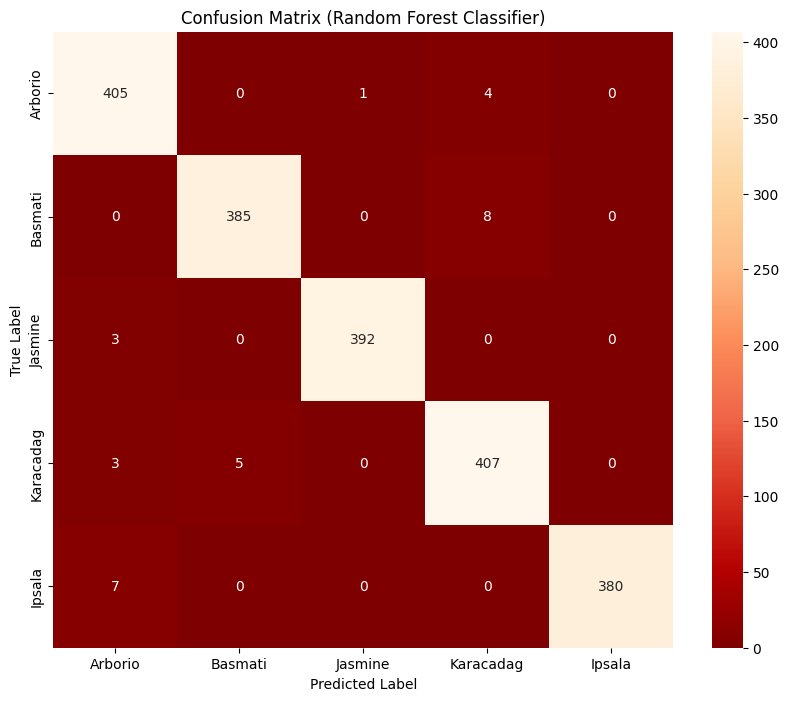

In [24]:
# ---confusion matrix---
cm = confusion_matrix(y_test, y_pred)
class_names = ["Arborio", "Basmati", "Jasmine", "Karacadag", "Ipsala"]
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="OrRd_r",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix (Random Forest Classifier)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Classification Report:
            Arborio   Basmati   Jasmine  Karacadag    Ipsala  accuracy  \
precision  0.968900  0.987179  0.997455   0.971360  1.000000    0.9845   
recall     0.987805  0.979644  0.992405   0.980723  0.981912    0.9845   
f1-score   0.978261  0.983397  0.994924   0.976019  0.990874    0.9845   

           macro avg  weighted avg  
precision   0.984979      0.984660  
recall      0.984498      0.984500  
f1-score    0.984695      0.984536  


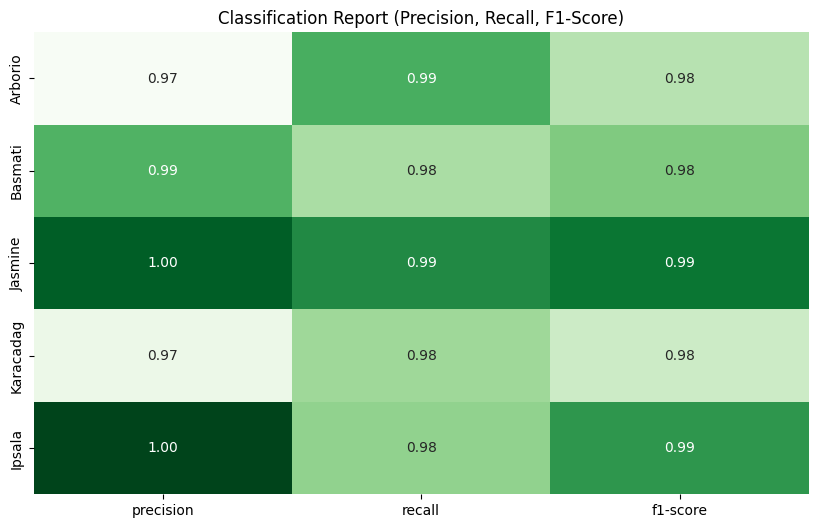

In [25]:
# ---Classification Report---
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("Classification Report:")
print(pd.DataFrame(report).iloc[:-1, :])  # Exclude averages for cleaner print

plt.figure(figsize=(10, 6))
sns.heatmap(
    report_df.iloc[:-3, :].drop(columns='support'),
    annot=True,
    cmap="Greens",
    fmt=".2f",
    cbar=False,
)
plt.title("Classification Report (Precision, Recall, F1-Score)")
plt.show()



In [36]:
def predict_image(image_path, model, scaler, target_size=(250, 250)):
    # Read and preprocess image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Read as color
    img = cv2.resize(img, target_size)  # Resize to target size

    # Flatten the image for prediction
    img_flat = img.reshape(1, -1)

    # Standardize the image using the fitted scaler
    img_scaled = scaler.transform(img_flat)

    # Make prediction
    pred = model.predict(img_scaled)
    proba = model.predict_proba(img_scaled)

    # Get class name and confidence
    class_names = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
    class_name = class_names[pred[0]]
    confidence = proba[0][pred[0]] * 100

    # Display results
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for displaying with matplotlib
    plt.title(f"Prediction: {class_name}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    return class_name, confidence

print("Prediction function defined successfully!")

Prediction function defined successfully!


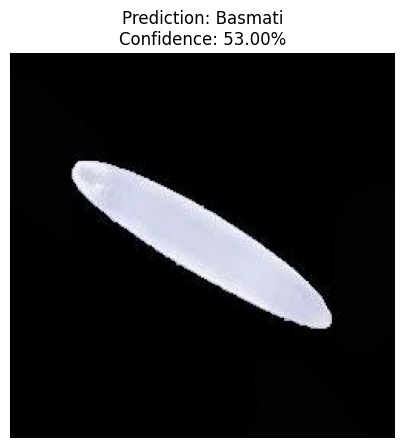

Predicted Class: Basmati
Confidence Percentage: 53.00%


In [37]:
model = rf
scaler = StandardScaler()
scaler.fit(x_train)
image_path = '/content/rice.jpg'

# Call the predict_image function
predicted_class_name, confidence_percentage = predict_image(image_path, model, scaler)

# Print the results
print(f"Predicted Class: {predicted_class_name}")
print(f"Confidence Percentage: {confidence_percentage:.2f}%")